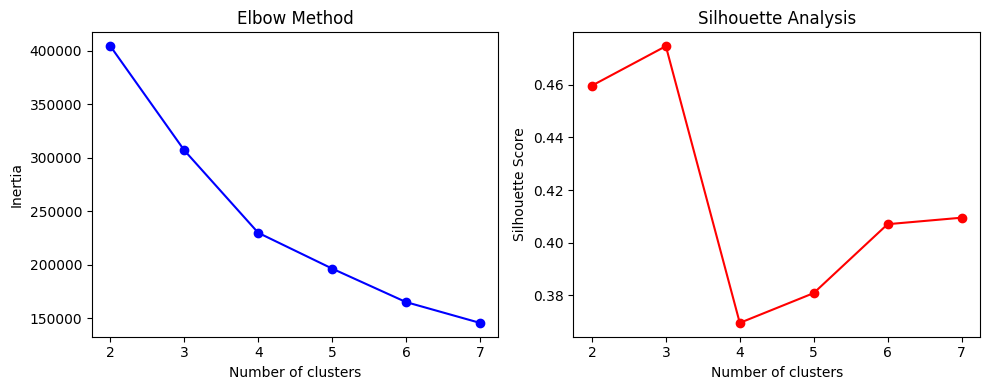

Cluster Summary:
         audienceScore  tomatoMeter  runtimeMinutes  scoreDifference  count
cluster                                                                    
0            58.927729    73.473362       83.593927        16.008020  73721
1            45.689088    27.222720       99.101217        22.561819   9366
2            68.214103    75.686457      110.195573        14.009203  40185
3            27.193996    75.077629       91.670371        47.883633  19619


In [1]:
# notebooks/02_descriptive_modeling.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

movies_clean = pd.read_csv('/Users/taksheel.partap/Desktop/CineMatch/data/cleaned_movies.csv')

# Prepare features for clustering
cluster_features = movies_clean[['audienceScore', 'tomatoMeter', 'runtimeMinutes', 'scoreDifference']].dropna()

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Determine optimal clusters using elbow method
inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

# Fit final model with optimal k
optimal_k = 4  # Based on elbow and silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
movies_clean['cluster'] = kmeans.fit_predict(scaled_features)

# Analyze cluster characteristics
cluster_summary = movies_clean.groupby('cluster').agg({
    'audienceScore': 'mean',
    'tomatoMeter': 'mean', 
    'runtimeMinutes': 'mean',
    'scoreDifference': 'mean',
    'title': 'count'
}).rename(columns={'title': 'count'})

print("Cluster Summary:")
print(cluster_summary)